In [1]:
import os
print(os.getcwd())

/Users/lea/Documents/Projects/movie-recommender/notebooks


In [2]:
import os

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print("Working directory is now:", os.getcwd())

Working directory is now: /Users/lea/Documents/Projects/movie-recommender


In [3]:
import pandas as pd

# MovieLens
ratings = pd.read_csv('data/ratings.csv')
links_ml = pd.read_csv('data/links_movielens.csv')

# Kaggle
movies = pd.read_csv('data/movies_metadata.csv', low_memory=False)
keywords = pd.read_csv('data/keywords.csv')
credits = pd.read_csv('data/credits.csv')
links_kaggle = pd.read_csv('data/links_kaggle.csv')

In [4]:
for name, df in [('ratings', ratings), ('links_ml', links_ml), 
                  ('movies', movies), ('keywords', keywords), 
                  ('credits', credits), ('links_kaggle', links_kaggle)]:
    print(f"{name}: {df.shape}")

ratings: (100836, 4)
links_ml: (9742, 3)
movies: (45466, 24)
keywords: (46419, 2)
credits: (45476, 3)
links_kaggle: (45843, 3)


In [5]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [6]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [7]:
movies[pd.to_numeric(movies['id'], errors='coerce').isna()] #converts id to number + checks for NaN values 

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
19730,- Written by Ørnås,0.065736,/ff9qCepilowshEtG2GYWwzt2bs4.jpg,"[{'name': 'Carousel Productions', 'id': 11176}...","[{'iso_3166_1': 'CA', 'name': 'Canada'}, {'iso...",1997-08-20,0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29503,Rune Balot goes to a casino connected to the ...,1.931659,/zV8bHuSL6WXoD6FWogP9j4x80bL.jpg,"[{'name': 'Aniplex', 'id': 2883}, {'name': 'Go...","[{'iso_3166_1': 'US', 'name': 'United States o...",2012-09-29,0,68.0,"[{'iso_639_1': 'ja', 'name': '日本語'}]",Released,...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35587,Avalanche Sharks tells the story of a bikini ...,2.185485,/zaSf5OG7V8X8gqFvly88zDdRm46.jpg,"[{'name': 'Odyssey Media', 'id': 17161}, {'nam...","[{'iso_3166_1': 'CA', 'name': 'Canada'}]",2014-01-01,0,82.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
keywords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46419 entries, 0 to 46418
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        46419 non-null  int64 
 1   keywords  46419 non-null  object
dtypes: int64(1), object(1)
memory usage: 725.4+ KB


In [9]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45476 entries, 0 to 45475
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cast    45476 non-null  object
 1   crew    45476 non-null  object
 2   id      45476 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [10]:
links_kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45843 entries, 0 to 45842
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  45843 non-null  int64  
 1   imdbId   45843 non-null  int64  
 2   tmdbId   45624 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 1.0 MB


In [11]:
ratings['rating'].describe()

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [12]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)

sparsity = 1 - (n_ratings / (n_users * n_movies))

print(f"Users: {n_users}")
print(f"Movies rated: {n_movies}")
print(f"Total ratings: {n_ratings}")
print(f"Sparsity: {sparsity:.4%}")

Users: 610
Movies rated: 9724
Total ratings: 100836
Sparsity: 98.3000%


In [13]:
ratings_per_user = ratings.groupby('userId').size()
ratings_per_movie = ratings.groupby('movieId').size()

print("Ratings per user:")
print(ratings_per_user.describe())

print("\nRatings per movie:")
print(ratings_per_movie.describe())

Ratings per user:
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

Ratings per movie:
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64


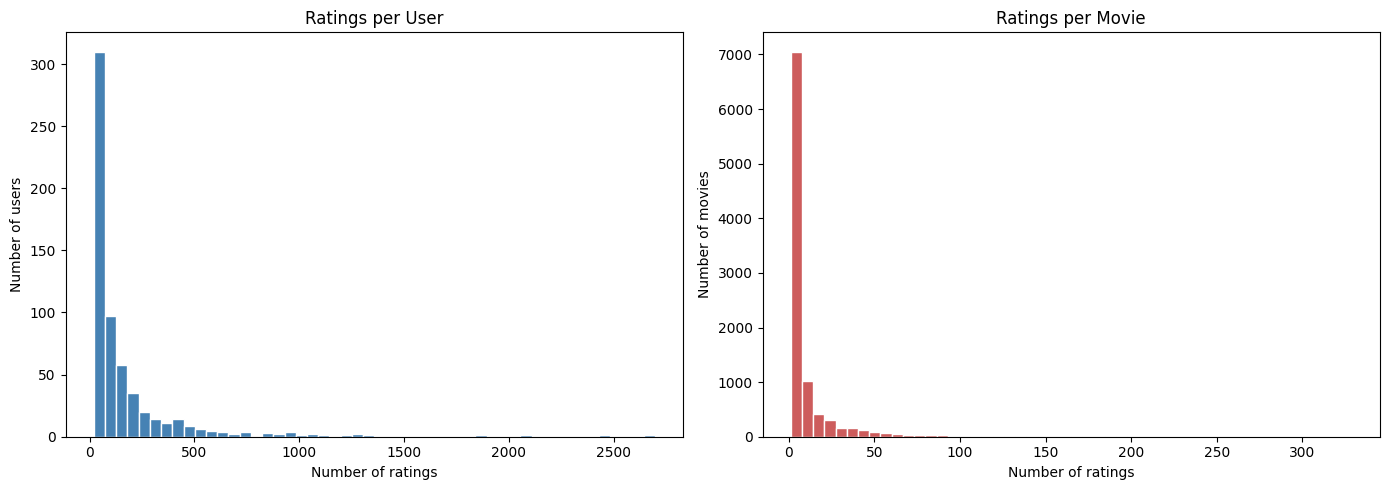

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ratings_per_user, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Ratings per User')
axes[0].set_xlabel('Number of ratings')
axes[0].set_ylabel('Number of users')

axes[1].hist(ratings_per_movie, bins=50, color='indianred', edgecolor='white')
axes[1].set_title('Ratings per Movie')
axes[1].set_xlabel('Number of ratings')
axes[1].set_ylabel('Number of movies')

plt.tight_layout()
plt.savefig('images/ratings_distribution.png', dpi=150)
plt.show()

In [15]:
movies['genres'].iloc[0]

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

In [16]:
movies['genres'].apply(type).value_counts()

genres
<class 'str'>    45466
Name: count, dtype: int64

In [17]:
movies['overview'].iloc[0]

"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences."

In [18]:
movies[movies['overview'].isna()][['title', 'release_date', 'vote_count']].head(10)

,title,release_date,vote_count
32,Wings of Courage,1996-09-18,4.0
300,Roommates,1995-03-01,7.0
634,Peanuts – Die Bank zahlt alles,1996-03-21,1.0
635,Happy Weekend,1996-03-14,0.0
641,The Superwife,1996-03-06,7.0
644,Und keiner weint mir nach,1996-02-29,0.0
679,Under The Domim Tree,1994-01-01,2.0
792,A Boy Called Hate,1996-05-22,2.0
802,Diebinnen,1996-06-20,1.0
821,The Day the Sun Turned Cold,1994-01-01,2.0


## Day 2 Findings 

**Ratings data:**
- 610 users, 9,724 rated movies, 100,836 ratings
- 98.3% sparsity in the user-item matrix
- Both ratings-per-user and ratings-per-movie are heavily right-skewed
  (median 70.5 vs mean 165.3 per user; median 3 vs mean 10.4 per movie)
- ~25% of movies have only 1 rating → collaborative filtering alone
  can't handle the long tail → empirical case for hybrid approach

**Movies metadata:**
- `id` column has 3 corrupted rows (shifted columns) → drop before Day 4 merge
- `genres` is a stringified list of dicts, 100% consistent format → parse later
- `overview` has 954 nulls, clustered in obscure/low-vote-count movies →
  low-impact, fallback to tagline/genres planned

**Links:**
- `links_kaggle.tmdbId` has 219 nulls → ~2% of MovieLens movies won't
  join to Kaggle metadata

In [19]:
print(movies.shape)
print(ratings.shape)

(45466, 24)
(100836, 4)


In [20]:
import ast

# Parse just for exploration - doesn't touch the original column
genre_lists = movies['genres'].apply(ast.literal_eval)
all_genres = genre_lists.explode()

genre_names = all_genres.apply(lambda x: x['name'] if isinstance(x, dict) else None)
genre_names.value_counts().head(20)

genres
Drama              20265
Comedy             13182
Thriller            7624
Romance             6735
Action              6596
Horror              4673
Crime               4307
Documentary         3932
Adventure           3496
Science Fiction     3049
Family              2770
Mystery             2467
Fantasy             2313
Animation           1935
Foreign             1622
Music               1598
History             1398
War                 1323
Western             1042
TV Movie             767
Name: count, dtype: int64

In [21]:
genre_lists.apply(len).describe()

count    45466.000000
mean         2.003827
std          1.131100
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          8.000000
Name: genres, dtype: float64

In [22]:
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies['release_date'].dt.year.describe()

count    45376.000000
mean      1991.881193
std         24.055360
min       1874.000000
25%       1978.000000
50%       2001.000000
75%       2010.000000
max       2020.000000
Name: release_date, dtype: float64

In [23]:
movies[movies['release_date'].dt.year < 1900][['title', 'release_date', 'vote_count']]

,title,release_date,vote_count
16252,The Four Troublesome Heads,1898-01-01,19.0
16257,The Human Pyramid,1899-05-20,2.0
17569,Edison Kinetoscopic Record of a Sneeze,1894-01-09,12.0
18914,"Ella Lola, a la Trilby",1898-01-01,1.0
18944,"Turkish Dance, Ella Lola",1898-09-30,2.0
...,...,...,...
45259,The Astronomer's Dream,1898-01-01,26.0
45262,The Temptation of St. Anthony,1898-01-01,6.0
45263,An Up-to-Date Conjurer,1899-01-01,12.0
45334,The Devil in a Convent,1899-01-01,10.0


In [24]:
movies[movies['release_date'].dt.year < 1890][['title', 'release_date', 'vote_count']]

,title,release_date,vote_count
34933,Man Walking Around a Corner,1887-08-18,17.0
34934,Accordion Player,1888-01-01,18.0
34937,Sallie Gardner at a Gallop,1878-06-14,25.0
34938,Traffic Crossing Leeds Bridge,1888-10-15,25.0
34940,Passage of Venus,1874-12-09,19.0
41602,Buffalo Running,1883-11-19,7.0


In [25]:
keywords['keywords'].iloc[0]

"[{'id': 931, 'name': 'jealousy'}, {'id': 4290, 'name': 'toy'}, {'id': 5202, 'name': 'boy'}, {'id': 6054, 'name': 'friendship'}, {'id': 9713, 'name': 'friends'}, {'id': 9823, 'name': 'rivalry'}, {'id': 165503, 'name': 'boy next door'}, {'id': 170722, 'name': 'new toy'}, {'id': 187065, 'name': 'toy comes to life'}]"

In [26]:
keyword_lists = keywords['keywords'].apply(ast.literal_eval)
keyword_lists.apply(len).describe()


count    46419.000000
mean         3.418428
std          4.670315
min          0.000000
25%          0.000000
50%          2.000000
75%          5.000000
max        149.000000
Name: keywords, dtype: float64

In [27]:
(keyword_lists.apply(len) == 0).sum()

np.int64(14795)

In [28]:
credits['crew'].iloc[0]

'[{\'credit_id\': \'52fe4284c3a36847f8024f49\', \'department\': \'Directing\', \'gender\': 2, \'id\': 7879, \'job\': \'Director\', \'name\': \'John Lasseter\', \'profile_path\': \'/7EdqiNbr4FRjIhKHyPPdFfEEEFG.jpg\'}, {\'credit_id\': \'52fe4284c3a36847f8024f4f\', \'department\': \'Writing\', \'gender\': 2, \'id\': 12891, \'job\': \'Screenplay\', \'name\': \'Joss Whedon\', \'profile_path\': \'/dTiVsuaTVTeGmvkhcyJvKp2A5kr.jpg\'}, {\'credit_id\': \'52fe4284c3a36847f8024f55\', \'department\': \'Writing\', \'gender\': 2, \'id\': 7, \'job\': \'Screenplay\', \'name\': \'Andrew Stanton\', \'profile_path\': \'/pvQWsu0qc8JFQhMVJkTHuexUAa1.jpg\'}, {\'credit_id\': \'52fe4284c3a36847f8024f5b\', \'department\': \'Writing\', \'gender\': 2, \'id\': 12892, \'job\': \'Screenplay\', \'name\': \'Joel Cohen\', \'profile_path\': \'/dAubAiZcvKFbboWlj7oXOkZnTSu.jpg\'}, {\'credit_id\': \'52fe4284c3a36847f8024f61\', \'department\': \'Writing\', \'gender\': 0, \'id\': 12893, \'job\': \'Screenplay\', \'name\': \'A

In [29]:
def get_director_count(crew_str):
    crew_list = ast.literal_eval(crew_str)
    directors = [person['name'] for person in crew_list if person['job'] == 'Director']
    return len(directors)

director_counts = credits['crew'].apply(get_director_count)
director_counts.value_counts().sort_index()

crew
0       887
1     41389
2      2719
3       282
4        75
5        39
6        23
7        19
8        10
9         4
10        7
11        6
12        4
13        1
14        2
15        1
21        1
26        1
27        1
30        2
36        1
41        1
42        1
Name: count, dtype: int64

In [30]:
movies[['runtime', 'vote_average']].describe()

,runtime,vote_average
count,45203.000000,45460.000000
mean,94.128199,5.618207
std,38.407810,1.924216
min,0.000000,0.000000
25%,85.000000,5.000000
50%,95.000000,6.000000
75%,107.000000,6.800000
max,1256.000000,10.000000


In [31]:
print("Movies with vote_average of 0:", (movies['vote_average'] == 0).sum())
print("Of those, movies with vote_count of 0 too:", ((movies['vote_average'] == 0) & (movies['vote_count'] == 0)).sum())

print("\nMovies with runtime of 0:", (movies['runtime'] == 0).sum())

Movies with vote_average of 0: 2998
Of those, movies with vote_count of 0 too: 2899

Movies with runtime of 0: 1558


In [32]:
movies['id'].duplicated().sum()

np.int64(30)

In [33]:
dup_ids = movies[movies['id'].duplicated(keep=False)].sort_values('id')
dup_ids[['id', 'title', 'release_date']].head(20)

,id,title,release_date
676,105045,The Promise,1995-02-16
1465,105045,The Promise,1995-02-16
44821,10991,Pokémon: Spell of the Unknown,2000-07-08
4114,10991,Pokémon: Spell of the Unknown,2000-07-08
5710,109962,Rich and Famous,1981-09-23
20899,109962,Rich and Famous,1981-09-23
23534,110428,Camille Claudel 1915,2013-03-13
4356,110428,Camille Claudel 1915,2013-03-13
24844,11115,Deal,2008-01-29
14012,11115,Deal,2008-01-29


## Day 3 Findings 

**Genres:**
- Avg ~2 genres per movie; Drama (20,265) and Comedy (13,182) dominate
- Confirms only genre is too coarse a signal for mood/concept-based differentiation

**Keywords:**
- ~32% of movies (14,795) don't have keywords = useful enhancer, not a
  reliable signal for the content-based engine

**Credits (director):**
- ~91% of movies have 1 director (clean, expected case)
- 887 movies have zero directors listed = needs fallback
- Small number of outliers (up to 42 "directors") = likely data quality
  issues, will cap director count during Day 7 extraction

**Release dates:**
- Early dates (1874-1899) are real historical/proto-cinema footage,
  not corrupted data = scoping decision for later, not a cleanup task

**Runtime & vote_average:**
- Both have 0-value placeholders representing "missing," not genuine
  zero values (confirmed via vote_count correlation) = treat as
  null-equivalent if used as features

**Duplicate IDs:**
- 30 duplicate rows (15 movies, each listed twice) — genuine exact
  duplicates, safe to drop with `drop_duplicates(subset='id')` before
  the Day 4 merge
  